
# Cheat Sheet: Simple Linear Regression / OLS with `statsmodels`

Quick reference for formulas, imports, and common code patterns. Every cell
below is runnable in isolation (after the imports cell) — copy-paste what you
need into your own project.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


## 0. Demo data (so every snippet below actually runs)

The rest of this notebook uses this tiny synthetic dataset and dataframe so
each cheat-sheet snippet is copy-paste-able AND runnable end to end. Swap in
your own `x`, `y`, or `df` when adapting these snippets to a real project.

In [2]:
rng = np.random.default_rng(0)
x = np.linspace(0, 10, 50)
y = 2 * x + 3 + rng.normal(0, 1, 50)

df = pd.DataFrame({'x_col': x, 'y_col': y})
df['const'] = 1.0
train, test = train_test_split(df, train_size=0.75, shuffle=True, random_state=42)

x_series = pd.Series(x)
y_series = pd.Series(y)
const_series = df['const']


## 1. Core Formulas

| Concept | Formula |
|---|---|
| Model | `y = β0 + β1*x + ε` |
| Slope estimator | `β̂1 = Σ(x_i - x̄)(y_i - ȳ) / Σ(x_i - x̄)²` |
| Intercept estimator | `β̂0 = ȳ - β̂1·x̄` |
| Residual | `e_i = y_i - ŷ_i` |
| Sum of squared errors | `SSE = Σ e_i²` |
| Pearson correlation | `r = (1/(n-1)) Σ [(x_i-x̄)/s_x][(y_i-ȳ)/s_y]` |
| Coefficient of determination | `r² = 1 - SS_res/SS_tot` |
| Durbin-Watson (lag-1 autocorr.) | `DW ≈ 2(1 - ρ̂₁)`; DW≈2 → none, DW→0 → positive, DW→4 → negative |
| Cook's distance | combines leverage + residual size to flag influential points |


## 2. Manual OLS estimator (from scratch)

In [3]:
def least_squares_method(x, y):
    x_mean = x.mean()
    y_mean = y.mean()
    beta1 = ((x - x_mean) * (y - y_mean)).sum(axis=0) / ((x - x_mean) ** 2).sum(axis=0)
    beta0 = y_mean - (beta1 * x_mean)
    return beta0, beta1

# usage:
# beta0_hat, beta1_hat = least_squares_method(x, y)


## 3. Fitting an OLS model with `statsmodels`

In [4]:
# ALWAYS add a constant column, or statsmodels fits a line through the origin.
X = sm.add_constant(x)          # x can be a 1D array/Series
model = sm.OLS(y, X).fit()
print(model.summary())

# Common accessors:
model.params          # coefficients (Series/array): [const, slope]
model.bse             # standard errors of coefficients
model.pvalues         # p-values
model.conf_int()      # 95% confidence intervals (default alpha=0.05)
model.rsquared        # R-squared
model.rsquared_adj    # Adjusted R-squared
model.fittedvalues    # y_hat for each observation
model.resid           # residuals
model.resid_pearson   # standardized residuals (unit variance)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     2613.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           1.63e-43
Time:                        20:43:47   Log-Likelihood:                -62.504
No. Observations:                  50   AIC:                             129.0
Df Residuals:                      48   BIC:                             132.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5488      0.240     10.611      0.0

array([ 0.66920824,  0.34264047,  1.21133246,  0.56263671, -0.20791751,
        0.80547404,  1.87123036,  1.42972139, -0.5127574 , -1.19180404,
       -0.47435839,  0.2691341 , -2.50339891, -0.0875508 , -1.30651746,
       -0.73814066, -0.54751308, -0.31054145,  0.50641654,  1.21079532,
       -0.17513417,  1.53165119, -0.85261872,  0.29932814,  0.91215357,
       -0.05431761, -1.0533321 , -1.28755045, -0.77676261, -0.01781783,
       -1.47191727, -0.5708427 , -0.54036742,  0.24427179, -0.16158617,
       -0.02582234, -1.22400349, -0.64336347,  0.38896532,  1.18449159,
       -2.03597841,  1.15332527,  0.93091352,  0.24852853, -0.37851307,
       -1.07692332,  0.95112919,  1.50627465,  1.29479615,  0.70293231])

### With a robust covariance estimator (heteroscedasticity-consistent SEs)

In [5]:
model_robust = sm.OLS(y, X).fit(cov_type='HC3')
print(model_robust.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     2251.
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           5.47e-42
Time:                        20:43:47   Log-Likelihood:                -62.504
No. Observations:                  50   AIC:                             129.0
Df Residuals:                      48   BIC:                             132.8
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5488      0.255      9.986      0.0

## 4. Correlation and R²

In [6]:
r = np.corrcoef(x, y)[0, 1]
r_squared = r ** 2

ss_res = np.sum((y - model.fittedvalues) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared_alt = 1 - ss_res / ss_tot


## 5. Diagnostic plots — copy-paste block

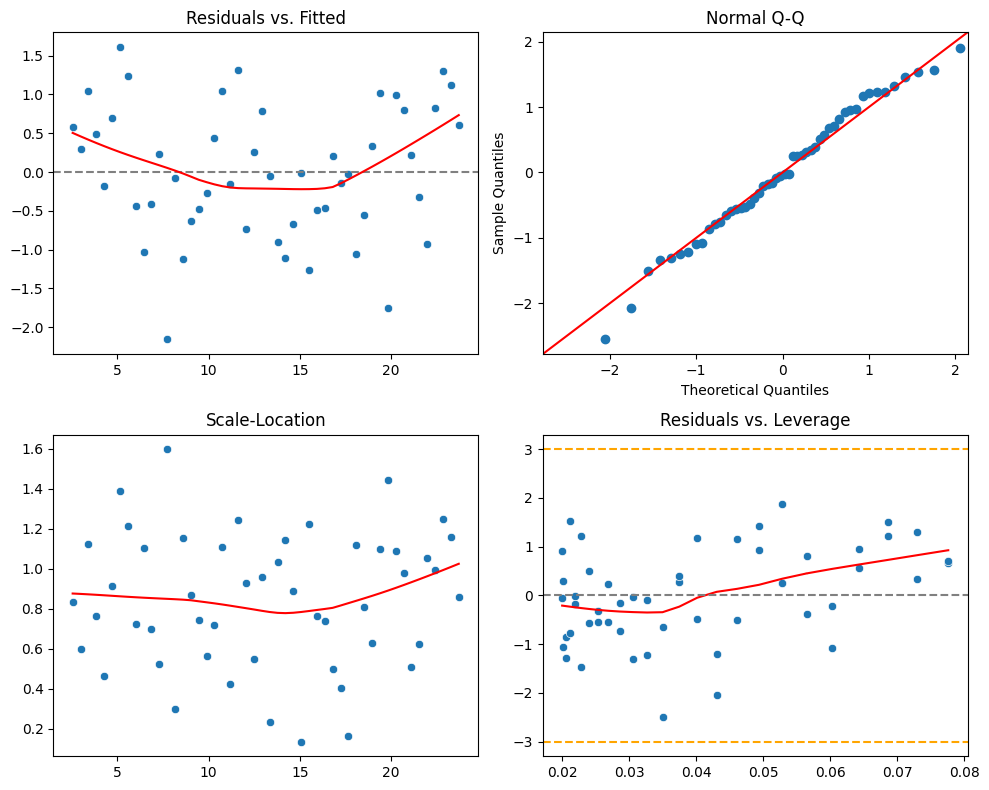

In [7]:
model_residuals = model.resid
fitted_value = model.fittedvalues
standardized_residuals = model.resid_pearson
sqrt_standardized_residuals = np.sqrt(np.abs(model.get_influence().resid_studentized_internal))
influence = model.get_influence()
leverage = influence.hat_matrix_diag
cooks_distance = model.get_influence().cooks_distance[0]

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Residuals vs. Fitted (linearity check)
lw1 = lowess(model_residuals, fitted_value)
sns.scatterplot(x=fitted_value, y=model_residuals, ax=ax[0, 0])
ax[0, 0].axhline(0, color='grey', linestyle='--')
ax[0, 0].plot(lw1[:, 0], lw1[:, 1], color='red')
ax[0, 0].set_title('Residuals vs. Fitted')

# Normal Q-Q (normality check)
sm.qqplot(model_residuals, fit=True, line='45', ax=ax[0, 1])
ax[0, 1].set_title('Normal Q-Q')

# Scale-Location (homoscedasticity check)
lw2 = lowess(sqrt_standardized_residuals, fitted_value)
sns.scatterplot(x=fitted_value, y=sqrt_standardized_residuals, ax=ax[1, 0])
ax[1, 0].plot(lw2[:, 0], lw2[:, 1], color='red')
ax[1, 0].set_title('Scale-Location')

# Residuals vs. Leverage (influence / outliers)
lw3 = lowess(standardized_residuals, leverage)
sns.scatterplot(x=leverage, y=standardized_residuals, ax=ax[1, 1])
ax[1, 1].plot(lw3[:, 0], lw3[:, 1], color='red')
ax[1, 1].axhline(0, color='grey', linestyle='--')
ax[1, 1].axhline(3, color='orange', linestyle='--')
ax[1, 1].axhline(-3, color='orange', linestyle='--')
ax[1, 1].set_title('Residuals vs. Leverage')

fig.tight_layout()
plt.show()


## 6. Serial correlation tools

Durbin-Watson: 1.5650313288387412


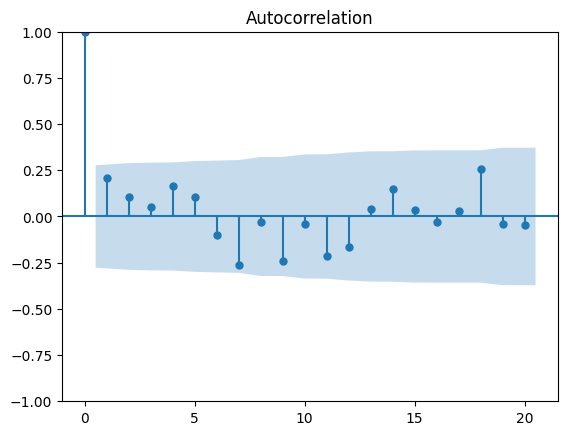

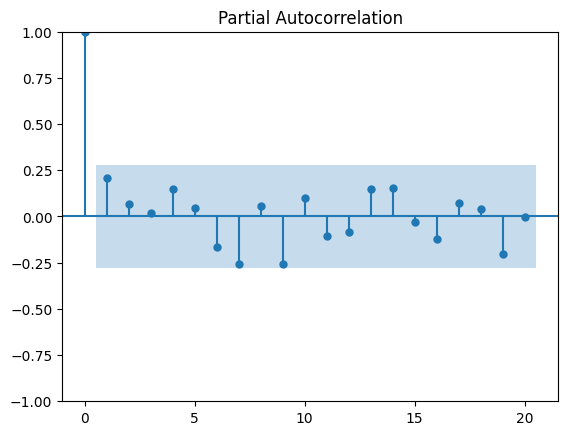

In [8]:
# ACF / PACF of a residual series or raw series
# (lags must be < number of observations; 50 is a typical choice for
# quarterly/monthly macro data with 100+ points -- use fewer for small n)
n_lags = min(20, len(model.resid) // 2 - 1)
fig = plot_acf(model.resid, alpha=0.05, lags=n_lags)
fig = plot_pacf(model.resid, alpha=0.05, lags=n_lags)

# Durbin-Watson is already printed in model.summary(); to compute manually:
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(model.resid)
print("Durbin-Watson:", dw_stat)

# First-order differencing (removes trend / much of the autocorrelation)
diffed_y = np.diff(y_series, n=1)
diffed_x = np.diff(x_series, n=1)
# NOTE: differencing drops the first observation -- match your constant column:
const_for_diff = const_series.iloc[:-1]
model_diff = sm.OLS(diffed_y, pd.concat([const_for_diff.reset_index(drop=True),
                                         pd.Series(diffed_x)], axis=1)).fit()


## 7. Train/test validation pattern

In [9]:
# train, test were created in the Section 0 demo-data cell above
model_train = sm.OLS(train['y_col'], train[['const', 'x_col']]).fit()

mae_train = mean_absolute_error(train['y_col'], model_train.predict(train[['const', 'x_col']]))
naive_mae_train = np.mean(np.abs(train['y_col'] - train['y_col'].mean()))

mae_test = mean_absolute_error(test['y_col'], model_train.predict(test[['const', 'x_col']]))
naive_mae_test = np.mean(np.abs(test['y_col'] - test['y_col'].mean()))
# A useful model: mae_train << naive_mae_train AND mae_test << naive_mae_test,
# with mae_train and mae_test in a similar ballpark.


## 8. Interpretation Quick-Reference

- **p-value < 0.05** and **95% CI excludes 0** → coefficient is "statistically significant" (standard caveats about multiple testing / p-hacking apply as always).
- **R² close to 1** → model explains most of the variance (in-sample fit; not the same as good out-of-sample prediction).
- **Durbin-Watson ≈ 2** → little evidence of lag-1 autocorrelation. **< 1.5** → investigate positive autocorrelation. **> 2.5** → investigate negative autocorrelation.
- **Cond. No. > ~30** (and especially in the hundreds/thousands) → numerical instability risk, often multicollinearity or unscaled variables.
- **Cook's distance > 0.5 (or > 1)** → point has outsized influence on the fit; investigate before deciding to keep/drop/transform.
- **Funnel-shaped Residuals vs. Fitted / Scale-Location plot** → heteroscedasticity; consider a variance-stabilizing transform (log, sqrt) or `cov_type='HC3'`.
- **Curved Residuals vs. Fitted plot** → linearity violated; consider adding polynomial terms, transforming a variable, or using a non-linear model.
- **Q-Q plot bowing away from the 45° line at the tails** → non-normal residuals (skew or heavy tails); consider transformations or robust regression.
